# Per-unit shuffle-based gridness threshold -- how it works

This notebook walks through, step by step and with pictures, the
**field-shuffle significance test** now implemented in `scores.py`
(`field_labels`, `shuffle_fields`, `GridScorer.shuffled_gridness_threshold`)
and used by `scripts/evaluate.py --shuffle_threshold`.

**Why this exists**: a fixed cutoff (e.g. `score_60 > 0.37`) applied to
every unit treats a unit with 2 firing fields and a unit with 15 firing
fields as if they had the same chance of looking hexagonal *purely by
accident*. Banino et al. 2018 (Supplementary Methods 3d) instead derive a
**separate threshold per unit**, from that unit's own field layout:

1. Segment the unit's ratemap into firing fields (watershed).
2. Relocate each field's peak to a uniformly random bin (keep its shape),
   refill everywhere else with the background level.
3. Score this shuffled map exactly like a real one.
4. Repeat 100x -> 100 "what gridness looks like by chance for *this*
   unit's fields" scores.
5. The unit's threshold = the 95th percentile of that null distribution.
6. The unit only counts as grid-like if its *real* score beats its *own*
   threshold.

**Caveat**: DeepMind never released the code for this specific analysis --
only the paper's prose description. The overall procedure below matches
that description, but implementation details it doesn't spell out (exact
field-boundary convention, how overlapping relocated fields combine, what
fills the vacated background) are this repo's own reasonable choices, not
verified against original source. See `scores.py`'s module docstring and
the README's "Known caveats" section.

We use a **synthetic, hand-built example** here (not a real trained unit)
so the field boundaries and shuffles are clean and easy to see -- but the
functions called below (`field_labels`, `shuffle_fields`,
`shuffled_gridness_threshold`) are the exact same code `evaluate.py` runs
on real bottleneck/LSTM activations.


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from scores import GridScorer, field_labels, shuffle_fields

rng = np.random.default_rng(42)


## 1. A synthetic "grid-cell-like" ratemap

A real grid cell fires in a *repeating* hexagonal lattice of fields
covering the whole environment -- not just one isolated hexagon of bumps.
(An isolated 7-bump hexagon actually scores poorly here: a single motif
without repetition doesn't give `calculate_sac`'s autocorrelogram enough
periodic structure to lock onto, and discretizing a 60-degree rotation on
a square pixel grid adds noise on top of that.) So we tile Gaussian bumps
across the full 2.2m room on a proper triangular lattice, plus a little
smooth per-bin noise -- this is structurally what a real 32x32 grid-cell
ratemap looks like.


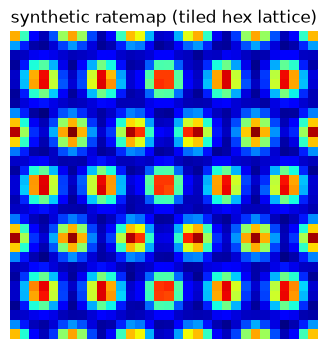

In [2]:
NBINS = 32
ROOM_HALF = 1.1  # 2.2m room, center-origin

xs, ys = np.meshgrid(np.linspace(-ROOM_HALF, ROOM_HALF, NBINS),
                      np.linspace(-ROOM_HALF, ROOM_HALF, NBINS))

# triangular/hexagonal lattice: two 60-degree-apart basis vectors, tiled
# across (and a bit past) the room so edge fields are only partially cut off
spacing = 0.45
sigma = 0.09
a1 = np.array([spacing, 0.0])
a2 = np.array([spacing * np.cos(np.deg2rad(60)), spacing * np.sin(np.deg2rad(60))])

ratemap = np.zeros((NBINS, NBINS))
for i in range(-4, 5):
    for j in range(-4, 5):
        cx, cy = i * a1[0] + j * a2[0], i * a1[1] + j * a2[1]
        if abs(cx) <= ROOM_HALF + 0.3 and abs(cy) <= ROOM_HALF + 0.3:
            ratemap += np.exp(-((xs - cx) ** 2 + (ys - cy) ** 2) / (2 * sigma ** 2))
ratemap += rng.normal(0, 0.01, size=ratemap.shape)
ratemap = np.clip(ratemap, 0, None)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(ratemap, cmap="jet", origin="lower")
ax.set_title("synthetic ratemap (tiled hex lattice)")
ax.axis("off")
plt.show()


## 2. Field segmentation (watershed)

`field_labels` assigns every bin to the local peak it "flows uphill" to
(steepest-ascent walk -- a dependency-free stand-in for watershed), then
keeps only the bins at or above 20% of that peak's height as the field
itself. Each color below is one field; dark purple (label 0) is
background.


found 39 fields


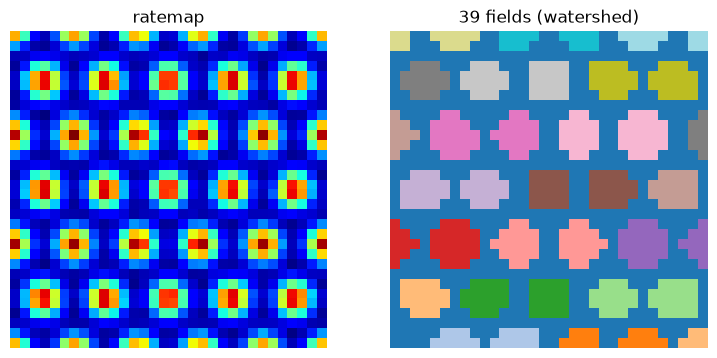

In [3]:
labels, n_fields = field_labels(ratemap, min_peak_frac=0.2)
print(f"found {n_fields} fields")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
axes[0].imshow(ratemap, cmap="jet", origin="lower")
axes[0].set_title("ratemap")
axes[0].axis("off")
axes[1].imshow(labels, cmap="tab20", origin="lower")
axes[1].set_title(f"{n_fields} fields (watershed)")
axes[1].axis("off")
plt.show()


## 3. One shuffle: relocate every field to a random bin

`shuffle_fields` cuts each field out (keeping its shape and values, just
its offset from its own peak), drops it at a brand-new random peak
location, and fills every bin not covered by a relocated field with the
original ratemap's background (non-field) mean -- so total activity level
stays comparable, only the *arrangement* of fields is randomized.


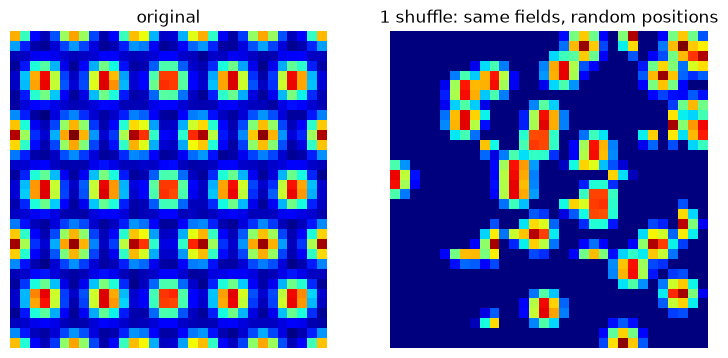

In [4]:
shuffled_once = shuffle_fields(ratemap, labels, n_fields, rng)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
axes[0].imshow(ratemap, cmap="jet", origin="lower")
axes[0].set_title("original")
axes[0].axis("off")
axes[1].imshow(shuffled_once, cmap="jet", origin="lower")
axes[1].set_title("1 shuffle: same fields, random positions")
axes[1].axis("off")
plt.show()


## 4. Score the real map and 100 shuffled maps

`GridScorer.get_scores` computes gridness the normal way (autocorrelogram,
then compare 30/60/90/120/150-degree rotations of it). We run it once on
the real ratemap, then 100 times on freshly-shuffled versions to build
this unit's own null distribution.


In [5]:
starts = [0.2] * 10
ends = np.linspace(0.4, 1.0, num=10).tolist()
mask_parameters = list(zip(starts, ends))
scorer = GridScorer(NBINS, ((-ROOM_HALF, ROOM_HALF), (-ROOM_HALF, ROOM_HALF)), mask_parameters)

real_score = scorer.get_scores(ratemap)[0]

n_shuffles = 100
null_scores = np.empty(n_shuffles)
for k in range(n_shuffles):
    shuffled = shuffle_fields(ratemap, labels, n_fields, rng)
    null_scores[k] = scorer.get_scores(shuffled)[0]

threshold = np.nanpercentile(null_scores, 95)
print(f"real score_60       = {real_score:.3f}")
print(f"shuffle threshold    = {threshold:.3f}  (95th pct of {n_shuffles} shuffles)")
print(f"grid-like?           = {real_score > threshold}")


real score_60       = 1.119
shuffle threshold    = 0.439  (95th pct of 100 shuffles)
grid-like?           = True


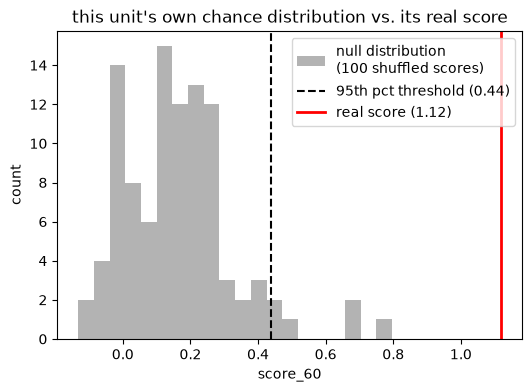

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(null_scores, bins=20, color="0.7", label="null distribution\n(100 shuffled scores)")
ax.axvline(threshold, color="black", linestyle="--", label=f"95th pct threshold ({threshold:.2f})")
ax.axvline(real_score, color="red", linewidth=2, label=f"real score ({real_score:.2f})")
ax.set_xlabel("score_60")
ax.set_ylabel("count")
ax.legend()
ax.set_title("this unit's own chance distribution vs. its real score")
plt.show()


## 5. Sanity check: this should be much easier to convince than a fixed 0.37

Since our 7 fields really are on a near-perfect hexagonal lattice, the
real score should clear the shuffle threshold comfortably. The equivalent
call used on real trained units in `scripts/evaluate.py` is
`GridScorer.shuffled_gridness_threshold(ratemap, n_shuffles=100)`, which
just wraps steps 2-4 above into one function.


In [7]:
threshold_fn = scorer.shuffled_gridness_threshold(ratemap, n_shuffles=100, rng=rng)
print(f"GridScorer.shuffled_gridness_threshold(...) = {threshold_fn:.3f}")
print(f"(should be close to the {threshold:.3f} we computed by hand above -- "
      "small difference is just a fresh batch of 100 random shuffles)")


GridScorer.shuffled_gridness_threshold(...) = 0.451
(should be close to the 0.439 we computed by hand above -- small difference is just a fresh batch of 100 random shuffles)
